# Exercise 5

In [87]:
import pandas as pd
import numpy as np

from scipy import stats
from scipy.stats import chi2_contingency


## Part 1: ANOVA

A teacher wants to investigate whether different teaching methods affect students’ exam scores. The dataset contains 50 students, each assigned to one of three teaching methods (A, B, or C).

Question: "Is there a difference in mean exam scores among students taught using three different teaching methods?"

- Independent variable (factor): Teaching Method (A, B, C)
- Dependent variable: Exam Score (numeric)

In [88]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/exam_scores.csv?raw=true"

df_exam_scores = pd.read_csv(url)
print(df_exam_scores)

    StudentID Method  Score
0           1      A     79
1           2      A     77
2           3      A     82
3           4      A     75
4           5      A     80
5           6      A     78
6           7      A     83
7           8      A     76
8           9      A     81
9          10      A     74
10         11      A     79
11         12      A     77
12         13      A     80
13         14      A     78
14         15      A     76
15         16      A     82
16         17      A     79
17         18      B     88
18         19      B     85
19         20      B     82
20         21      B     87
21         22      B     90
22         23      B     84
23         24      B     86
24         25      B     83
25         26      B     88
26         27      B     85
27         28      B     86
28         29      B     87
29         30      B     89
30         31      B     84
31         32      B     90
32         33      B     85
33         34      B     88
34         35      C

Calculate the number of students in each teaching method.

In [89]:
method_counts = df_exam_scores['Method'].value_counts()
print(method_counts)

Method
A    17
B    17
C    16
Name: count, dtype: int64


Compute the mean and standard deviation of exam scores for each group.

In [90]:
group_stats = df_exam_scores.groupby('Method')['Score'].agg(['mean', 'std'])
print(group_stats)

             mean       std
Method                     
A       78.588235  2.575336
B       86.294118  2.365500
C       71.937500  1.768945


Use a plot to show the exam scores by teaching method.

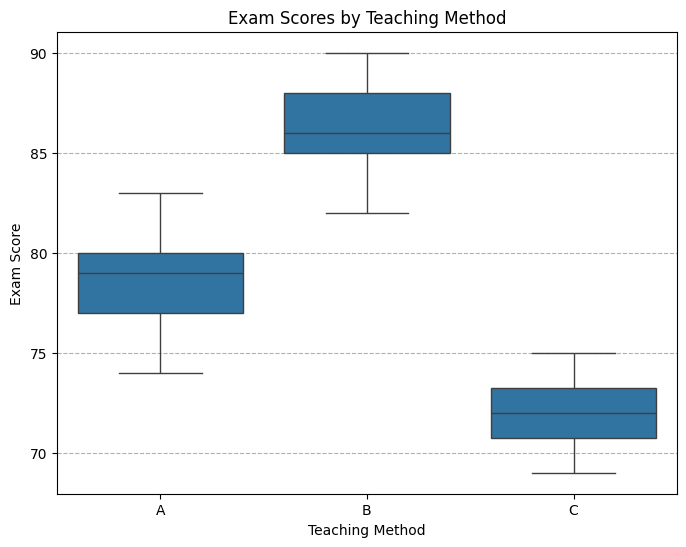

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Method', y='Score', data=df_exam_scores)
plt.title('Exam Scores by Teaching Method')
plt.xlabel('Teaching Method')
plt.ylabel('Exam Score')
plt.grid(axis='y', linestyle='--')
plt.show()

Null: "There is a statistically significant difference in mean exam scores among the teaching methods.

Alternative: There is no statistically significant difference in mean exam scores among the teaching methods.

Perform the ANOVA Test
- Use scipy.stats.f_oneway to conduct a one-way ANOVA.
- Report the F-statistic and p-value.
- Using a significance level of α = 0.05, state whether you reject or fail to reject H₀.

In [92]:
scores_method_A = df_exam_scores[df_exam_scores['Method'] == 'A']['Score']
scores_method_B = df_exam_scores[df_exam_scores['Method'] == 'B']['Score']
scores_method_C = df_exam_scores[df_exam_scores['Method'] == 'C']['Score']

f_statistic, p_value = stats.f_oneway(scores_method_A, scores_method_B, scores_method_C)

print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

alpha = 0.05
if p_value < alpha:
    print(f"Since the p-value ({p_value:.3f}) is less than alpha ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in mean exam scores among the teaching methods.")
else:
    print(f"Since the p-value ({p_value:.3f}) is greater than or equal to alpha ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in mean exam scores among the teaching methods.")

F-statistic: 165.18
P-value: 0.000
Since the p-value (0.000) is less than alpha (0.05), we reject the null hypothesis.


Interpret the results. What does it say about the relationship between teaching method and exam scores?

In [93]:
print("The ANOVA test found a statistically significant difference in mean exam scores among students taught using three different teaching methods.")
print("This indicates that at least one teaching method leads to significantly different exam scores compared to the others.")

The ANOVA test found a statistically significant difference in mean exam scores among students taught using three different teaching methods.
This indicates that at least one teaching method leads to significantly different exam scores compared to the others.


## Part 2: Chi-squared

A survey was conducted to see if there is a relationship between gender and littering behavior.

Question:
"Is gender associated with littering behavior?"

Each row represents one person.

In [94]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/litteringdata.csv?raw=true"

df_littering_data = pd.read_csv(url)
df_littering_data
print(df_littering_data)

    ID  Gender Litter
0    1    Male    Yes
1    2    Male    Yes
2    3    Male    Yes
3    4    Male    Yes
4    5    Male    Yes
5    6    Male    Yes
6    7    Male    Yes
7    8    Male    Yes
8    9    Male    Yes
9   10    Male    Yes
10  11    Male    Yes
11  12    Male    Yes
12  13    Male     No
13  14    Male     No
14  15    Male     No
15  16    Male     No
16  17    Male     No
17  18    Male     No
18  19    Male     No
19  20    Male     No
20  21  Female    Yes
21  22  Female    Yes
22  23  Female    Yes
23  24  Female    Yes
24  25  Female    Yes
25  26  Female    Yes
26  27  Female     No
27  28  Female     No
28  29  Female     No
29  30  Female     No
30  31  Female     No
31  32  Female     No
32  33  Female     No
33  34  Female     No
34  35  Female     No
35  36  Female     No
36  37  Female     No
37  38  Female     No
38  39  Female     No
39  40  Female     No


Count the number of observations in each category for Gender and Litter separately.

In [95]:
gender_counts = df_littering_data['Gender'].value_counts()
litter_counts = df_littering_data['Litter'].value_counts()

print("Gender Counts:")
print(gender_counts)
print("\nLitter Counts:")
print(litter_counts)

Gender Counts:
Gender
Male      20
Female    20
Name: count, dtype: int64

Litter Counts:
Litter
No     22
Yes    18
Name: count, dtype: int64


Using `pd.crosstab()`, create a contingency table showing counts of littering behavior for each gender.
- Write down the row totals, column totals, and grand total from the table.

In [96]:
contingency_table = pd.crosstab(df_littering_data['Gender'], df_littering_data['Litter'])
print("Contingency Table (Gender vs. Litter):")
print(contingency_table)

row_totals = contingency_table.sum(axis=1)
print("\nRow Totals:")
print(row_totals)

col_totals = contingency_table.sum(axis=0)
print("\nColumn Totals:")
print(col_totals)

grand_total = contingency_table.sum().sum()
print(f"\nGrand Total: {grand_total}")

Contingency Table (Gender vs. Litter):
Litter  No  Yes
Gender         
Female  14    6
Male     8   12

Row Totals:
Gender
Female    20
Male      20
dtype: int64

Column Totals:
Litter
No     22
Yes    18
dtype: int64

Grand Total: 40


State the null hypothesis (H₀) and alternative hypothesis (H₁) for this chi-squared test.

Null Hypothesis (H₀): There is no association between gender and littering behavior.

Alternative Hypothesis (H₁): There is an association between gender and littering behavior.

Use scipy.stats.chi2_contingency to calculate:
- Chi-squared statistic
- p-value
- Degrees of freedom

Using a significance level of `α = 0.05`, determine whether to reject or fail to reject H₀.


In [97]:
chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value:.3f}")
print(f"Degrees of freedom: {degrees_of_freedom}")

alpha = 0.05
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than alpha ({alpha}), we reject the null hypothesis.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than or equal to alpha ({alpha}), we fail to reject the null hypothesis.")

Chi-squared statistic: 2.53
P-value: 0.112
Degrees of freedom: 1

Since the p-value (0.112) is greater than or equal to alpha (0.05), we fail to reject the null hypothesis.


Interpret your results. Is there evidence that gender and littering behavior are associated?

Based on the chi-squared test, with a p-value of 0.112 (which is greater than our significance level of 0.05), we fail to reject the null hypothesis. This means there is no statistically significant evidence to suggest an association between gender and littering behavior in this sample.
